## Напишите заголовок проекта здесь

- Автор: ArtemSokolski
- Дата: 27.04.26

### Цели и задачи проекта


**Цель**: Провести исследовательский анализ рынка Москвы в сфере общественного питания.
**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - Изучить категории
    - Изучить административные районы Москвы
    - Изучить соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения
    - Исследовать количество посадочных мест в заведениях
    - Исследовать рейтинг заведений
    - Исследовать самую сильную корреляцию для рейтинга заведений
    - Сгруппировать данные по названиям заведений и найти топ-15 популярных сетей в Москве
    - Изучить вариацию среднего чека заведения (столбец middle_avg_bill) в зависимости от района Москвы
4. Сформулировать выводы по проведённому анализу:
    - Общий обзор проделанной работы
    - Ответы на исследовательские вопросы, или главные выводы
    - Рекомендации на основе анализа данных

### Описание данных

В проекте будут использованы данные датасета `/datasets/rest_info.csv` и датасета `/datasets/rest_price.csv`
    
    
**Описание данных датасета `/datasets/rest_info.csv`:**

    - name - название заведения
    - address — адрес заведения
    - district — административный район, в котором находится заведение, например Центральный административный округ
    - category — категория заведения, например «кафе», «пиццерия» или «кофейня»
    - hours — информация о днях и часах работы
    - rating — рейтинг заведения по оценкам пользователей в Яндекс Картах
    - chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым
    - seats — количество посадочных мест
    
**Описание данных датасета `/datasets/rest_price.csv`:**

    - price - категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее
    - avg_bill — строка, которая хранит среднюю стоимость заказа в виде диапазона
    - middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»
    - middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»
    

### Содержимое проекта

1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных
4. Итоговый вывод и рекомендации

## 1. Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

#Чтобы в тетради работали инструменты библиотеки phik, установим её с помощью кода
!pip install phik==0.11.0

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

     |████████████████████████████████| 594 kB 1.9 MB/s eta 0:00:01
  Created wheel for phik: filename=phik-0.11.0-py3-none-any.whl size=599734 sha256=ab5957cf612909ad9f5f2ec74adf3a616131f33c2d691b4daef7d15de27891f5
  Stored in directory: /home/jovyan/.cache/pip/wheels/f4/62/e1/886fe092e3a53f783898861c58016ca757fcd0523db7c2cefe
Successfully built phik


In [2]:
# Выгружаем данные в переменные bank_df и clients_df
info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомимся с данными датасета '/datasets/rest_info.csv' — выведем первые строки методом head(), а информацию о датафрейме методом info():

In [3]:
# Выводим первые строки датафрейма на экран
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим информацию о датафрейме
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [5]:
# Выводим разброс значений, максимум, минимум, среднее и медиану.
info_df.describe()

,rating,chain,seats
count,8406.000000,8406.000000,4795.000000
mean,4.229895,0.381275,108.421689
std,0.470348,0.485729,122.833396
min,1.000000,0.000000,0.000000
25%,4.100000,0.000000,40.000000
50%,4.300000,0.000000,75.000000
75%,4.400000,1.000000,140.000000
max,5.000000,1.000000,1288.000000


Датасет `/datasets/rest_info.csv` содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания

После анализа данных датасета можно сделать следующие выводы:
- Значение в столбце `seats` представлено в виде числа с плавающей точкой, стоит заменить на целочисленный тип 
- Размерность данных в `seats` можно оптимизировать
- Пропуски содержатся в столбцах `hours` и `seats`
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию

Теперь познакомимся с данными датасета `/datasets/rest_price.csv`.

In [6]:
# Выводим первые строки датафрейма на экран
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# Выводим информацию о датафрейме
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [8]:
# Выводим разброс значений, максимум, минимум, среднее и медиану.
price_df.describe()

,middle_avg_bill,middle_coffee_cup
count,3149.000000,535.000000
mean,958.053668,174.721495
std,1009.732845,88.951103
min,0.000000,60.000000
25%,375.000000,124.500000
50%,750.000000,169.000000
75%,1250.000000,225.000000
max,35000.000000,1568.000000


Датасет `/datasets/rest_price.csv` содержит 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке в заведениях общественного питания

После анализа данных датасета можно сделать следующие выводы:
- Значения в столбцах `middle_avg_bill` и `middle_coffee_cup` приведем к целочисленному типу данных
- Размерность данных в `middle_avg_bill` и `middle_coffee_cup` можно оптимизировать
- Пропуски содержатся в столбцах `price`, ` avg_bill`, `middle_avg_bill` и особенно большое количество в `middle_coffee_cup`
- Значения в столбцах соответствуют описанию

---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

**Промежуточный вывод:**

Предоставленные данные имеют достаточный объём для анализа:
- rest_info.csv содержит 8406 записей (из них 4795 с информацией о посадочных местах), rest_price.csv — 4058 записей. Данные в целом соответствуют описанию, однако в обоих датасетах присутствуют пропуски (в hours и seats в первом, в price, avg_bill, middle_avg_bill, middle_coffee_cup — во втором)
- Типы данных в основном корректны, но seats, middle_avg_bill и middle_coffee_cup хранятся как float64, стоит привести их к целочисленному типу
- Стоит обратить внимание на разное количество строк датасетов

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [9]:
# Соединяем данные в единый датафрейм df
df = info_df.merge(price_df, on='id', how = 'left')

In [10]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [11]:
# Комментарий ревьюера
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
# только не надо эту копию потом использовать в проекте
temp = df.copy() 
len(temp)

8406

In [12]:
# Создадим копию датасета и замерим длину до его обработки
temp = df.copy()
len(temp)

8406

## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

In [13]:
# Преобразуем типы данных для столбцов 'seats', 'middle_avg_bill' и 'middle_coffee_cup'
df['seats'] = df['seats'].astype('Int64')
df['middle_avg_bill'] = df['middle_avg_bill'].astype('Int64')
df['middle_coffee_cup'] = df['middle_coffee_cup'].astype('Int64')

In [14]:
#  Снизим размерность столбца 'rating'
df['rating'] = df['rating'].astype('float32') 

In [15]:
# Снизим размерность столбцов 'chain', 'middle_avg_bill', 'middle_coffee_cup'
df['chain'] = pd.to_numeric(df['chain'], downcast = 'integer')
df['middle_avg_bill'] = pd.to_numeric(df['middle_avg_bill'], downcast = 'float')
df['middle_coffee_cup'] = pd.to_numeric(df['middle_coffee_cup'], downcast = 'float')

In [16]:
# Проверим типы данных с помощью атрибута dtypes
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   int8
seats                  Int64
price                 object
avg_bill              object
middle_avg_bill      float32
middle_coffee_cup    float32
dtype: object

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [17]:
# Считаем количество пропусков в каждом столбце и применяем метод isna()
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [18]:
# Подсчитываем долю строк с пропусками
df.isna().sum() / df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

In [19]:
# Комментарий ревьюера
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
hours,536,0.0638
seats,3611,0.4296
price,5091,0.6056
avg_bill,4590,0.5460
middle_avg_bill,5257,0.6254
middle_coffee_cup,7871,0.9364


In [20]:
# Создаем функцию для вывода таблицы с данными о количестве и доли пропусков в данных
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
hours,536,0.0638
seats,3611,0.4296
price,5091,0.6056
avg_bill,4590,0.5460
middle_avg_bill,5257,0.6254
middle_coffee_cup,7871,0.9364


В датафрейме обнаружено:
- 536 пропусков в столбце `hours` — это 6% данных
- 3611 пропусков в столбце `seats` — это 42% данных
- 5091 пропусков в столбце `price` — 60% данных 
- 4590 пропусков в столбце `avg_bill` — 54% данных
- 5257 пропусков в столбце `middle_avg_bill` — 62% данных
- 7871 пропусков в столбце `middle_coffee_cup` — 93% данных


**Основная причина пропусков заключается в том, что не все цены и категории попали в датасет с заведениями**

In [21]:
# Комментарий ревьюера
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df)
print(a, b, round((a-b)/a*100, 2))

8406 8406 0.0


In [22]:
# Создадим новый столбец с указателем, есть ли пропуск в столбце hours
df['hours_missing'] = df['hours'].isna()

- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения

In [23]:
# Проверяем явные дубликаты
df.duplicated().sum()

0

In [24]:
# Проверяем неявные дубликаты по столбцу 'id'
df.duplicated(subset='id').sum()

0

In [25]:
# нормализуем данные в текстовом столбце 'name'
df['name'] = df['name'].str.lower().str.strip()
df.duplicated(subset = 'name').sum()

2894

In [26]:
# нормализуем данные в текстовом столбце 'name'
df['address'] = df['address'].str.lower().str.strip()
df.duplicated(subset = 'address').sum()

2654

In [27]:
# Проверяем на неявные дубликаты по 'name' и 'address'
df.duplicated(subset=['name', 'address']).sum()

4

In [28]:
# посмотрим на эти строки
df[df.duplicated(subset=['name', 'address'], keep=False)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,hours_missing
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,<NA>,NaN,NaN,NaN,NaN,False
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,<NA>,NaN,NaN,NaN,NaN,False
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,NaN,NaN,NaN,NaN,False
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,NaN,NaN,NaN,NaN,False
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,NaN,NaN,NaN,NaN,False
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,NaN,NaN,NaN,NaN,False
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,NaN,NaN,NaN,NaN,False
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276,NaN,NaN,NaN,NaN,True


In [29]:
# Удалим неявные дубликаты по одинаковому имени и адресу
df = df.drop_duplicates(subset = ['name', 'address'], keep = 'first')

- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [30]:
# Создаём столбец 'is_24_7'
df['is_24_7'] = df['hours'] == 'ежедневно, круглосуточно'

In [31]:
# Комментарий ревьюера
df['is_24_7'].value_counts()

False    7672
True      730
Name: is_24_7, dtype: int64

In [32]:
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 535
rating                  0
chain                   0
seats                3610
price                5087
avg_bill             4586
middle_avg_bill      5253
middle_coffee_cup    7867
hours_missing           0
is_24_7                 0
dtype: int64

In [33]:
# Комментарий ревьюера
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8402 
 Удалено строк в датасете после обработки 4 
 Процент потерь 0.05


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

**В ходе предобработки данных были выполнены следующие действия:**

В ходе предобработки данных удалено 539 строк: 536 строк с пропущенными значениями в столбце hours (6% данных) и 3 строки-дубликата с полностью совпадающими названиями и адресами. Таким образом, для дальнейшего анализа осталось 7867 заведений (94% от исходного объёма).


<font color='DarkBlue'><b>**Общая информация о данных:**

- Размер объединённого датасета: 8406 строк - 13 столбцов
- Размер после всех преобразований: 8402 строк - 14 столбцов

**Типы данных:**

- Преобразованы: 'seats', 'middle_avg_bill', 'middle_coffee_cup' приведены к Int64, 'rating' к float32, 'chain' к int8
- Все столбцы имеют корректные типы

**Пропуски:**

- До обработки: пропуски в 6 столбцах (наибольший - 93% в 'middle_coffee_cup')
- После обработки: пропуски в столбцах 'seats', 'price', 'avg_bill', 'middle_avg_bill', 'middle_coffee_cup' сохранены

**Дубликаты:**

- Явные дубликаты: 0
- Неявные дубликаты (по 'name' + 'address'): 4 строки
- Метод обработки: удаление с keep='first'
- После обработки остался датафрейм с 8402 строками данных

**Созданные столбцы:**

- 'is_24_7' — индикатор круглосуточной работы (730 заведений)
- 'hours_missing' - с пропусками в 'hours' (536 заведений)

**Итоговое состояние данных:**

- 8402 строк готовы к исследовательскому анализу

</b></font><br>

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [34]:
# Проверяем распределение данных по значениям столбца category
print('Распределение данных по значениям столбца category:')
df['category'].value_counts()

Распределение данных по значениям столбца category:


кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

In [35]:
# Проверяем распределение данных по значениям столбца category в относительных значениях
print('Распределение данных в относительных значениях столбца category:')
df['category'].value_counts(normalize=True)

Распределение данных в относительных значениях столбца category:


кафе               0.282790
ресторан           0.243037
кофейня            0.168174
бар,паб            0.090931
пиццерия           0.075339
быстрое питание    0.071769
столовая           0.037491
булочная           0.030469
Name: category, dtype: float64

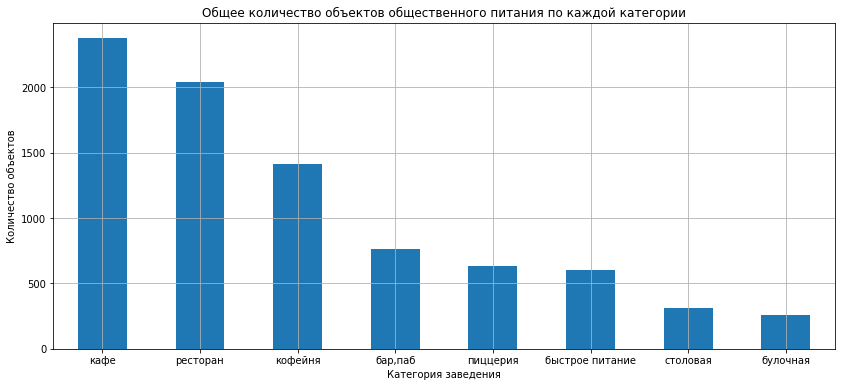

In [36]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(14, 6))

# Строим столбчатую диаграмму с помощью pandas чере1з plot(kind='bar')
df['category'].value_counts().plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Общее количество объектов общественного питания по каждой категории'
)

# Настраиваем оформление графика
plt.xlabel('Категория заведения')
plt.ylabel('Количество объектов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

</font><font color='Blue'><b>
Конкуренция выше всего именно в сегментах кафе, ресторанов и кофеен — занимая 68% рынка, они же привлекают основную базу клиентов. Для открытия нового заведения это значит: либо бороться за долю в высокой конкуренции, либо выбирать менее насыщенные категории (булочные, столовые), где занято всего 3–4% рынка, но и спрос может быть ниже
    
Рекомендуется при выборе категории опираться не только на общее количество, но и на плотность заведений в конкретном районе 
</b></font><br>

<font color='DarkMagenta'>👉 Вывод: Две трети рынка заняты «легкими» форматами, сегментированными на «посидеть» и «перекусить»

1. <b>Группировка и интерпретация</b><br>
- Рынок общепита Москвы не монолитен: <b>кафе и рестораны суммарно занимают более половины всех заведений (52.5%)</b>. Однако, если объединить их с кофейнями и барами, получится, что <b>~78% точек</b> относятся к форматам, ориентированным на <b>длительное времяпрепровождение</b> (посидеть, поработать, встретиться).<br>

2. <b>Сравнение и бизнес-смысл</b>
-   <b>Кафе (28%)</b> и <b>Рестораны (24%)</b> — абсолютные лидеры. Это «золотая середина»: первый привлекает демократичностью, второй — статусом.
-   <b>Кофейни (17%)</b> — третий по величине сегмент, что подтверждает тренд на «кофе с собой» и коворкинг.
-   <b>Бары (9%)</b> замыкают топ-4, показывая стабильный, но более узкий спрос на вечерний досуг.
-   <b>Быстрое питание (7%)</b> и <b>Столовые (3.7%)</b> находятся в минорной позиции, что говорит о высокой конкуренции со стороны уличной еды и форматов «готового обеда» в магазинах.<br>

3. <b>Рекомендации</b>
-   <b>Для массового трафика:</b> Открывать <b>кафе</b> (универсальный формат) или <b>кофейню</b> (быстрая окупаемость).
-   <b>Для высокой маржи:</b> Внедрять гибридные форматы (кофейня-пекарня, ресторан-бар), чтобы захватить аудиторию нескольких сегментов.
-   <b>Аутсайдерам (столовые, бургерные):</b> Выход в спальные районы с высоким пешеходным трафиком, где спрос на «дешевый обед» остается неудовлетворённым из-за удаленности от офисов.</font>

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

**Выполним извлечение данных и визуализацию по всем районам Москвы:**

In [37]:
# Проверяем распределение данных по значениям столбца district
print('Распределение данных по значениям столбца district:')
df['district'].value_counts()

Распределение данных по значениям столбца district:


Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

In [38]:
# Проверяем распределение данных по значениям столбца district в относительных значениях
print('Распределение данных по значениям столбца district:')
df['district'].value_counts(normalize=True)

Распределение данных по значениям столбца district:


Центральный административный округ         0.266841
Северный административный округ            0.106879
Южный административный округ               0.106165
Северо-Восточный административный округ    0.105927
Западный административный округ            0.101166
Восточный административный округ           0.094977
Юго-Восточный административный округ       0.084980
Юго-Западный административный округ        0.084385
Северо-Западный административный округ     0.048679
Name: district, dtype: float64

In [39]:
# выведем названия всех округов
df['district'].unique()

array(['Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Западный административный округ',
       'Центральный административный округ',
       'Восточный административный округ',
       'Юго-Восточный административный округ',
       'Южный административный округ',
       'Юго-Западный административный округ'], dtype=object)

In [40]:
# сократим названия округов для лучшей визуализации в графике
df['district'] = df['district'].str.replace(' административный округ', '')

In [41]:
# проверим замены
df['district'].unique()

array(['Северный', 'Северо-Восточный', 'Северо-Западный', 'Западный',
       'Центральный', 'Восточный', 'Юго-Восточный', 'Южный',
       'Юго-Западный'], dtype=object)

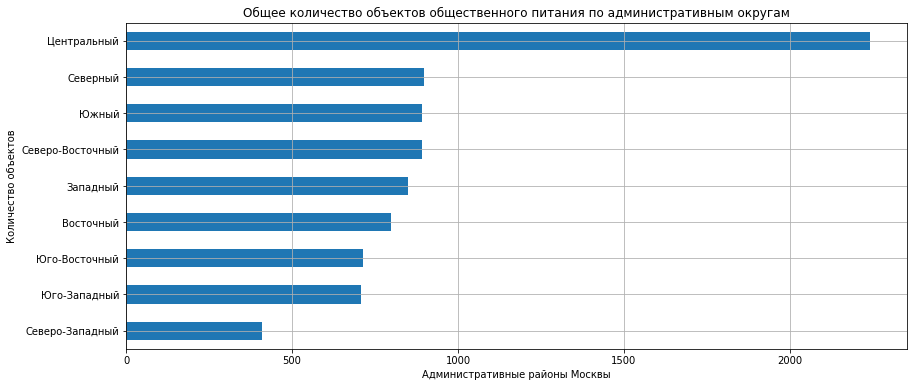

In [42]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(14, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['district'].value_counts().sort_values(ascending = True).plot(
               kind='barh', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Общее количество объектов общественного питания по административным округам'
)

# Настраиваем оформление графика
plt.xlabel('Административные районы Москвы')
plt.ylabel('Количество объектов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

</font><font color='Blue'><b>
Вывод:
- Центральный округ - абсолютный лидер: сосредоточено 28,1% всех заведений общественного питания, что почти в 3 раза больше, чем у ближайшего района - Северного округа (10,7%), это говорит о максимальной концентрации заведений в центре города

- Остальные округа - (Северный, Южный, Северо-Восточный) имеют близкие показатели - 10,5–10,7%, образуя группу с высойо плотностью, западный (10,0%) и Восточный (9,2%) имеют показатели чуть меньше

- Аутсайдеры - Юго-Восточный (8,3%), Юго-Западный (8,0%) и особенно Северо-Западный (всего 4,7%) - самый низкий показатель

- Бизнес-смысл - открытие заведения в ЦАО означает максимальную конкуренцию, в Северо-Западном округе конкуренция минимальная
</b></font><br>

**Выполним извлечение данных и визуализацию по Центральному административному округу Москвы:**

In [43]:
# создадим новый датафрейм с фильтром для центрального округа
df_moscow_district = df[df['district'] == 'Центральный']

In [44]:
# произведем группировку по категориям и посчитаем количество заведений
df_moscow_district.groupby('category')['id'].count().sort_values(ascending = False)

category
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: id, dtype: int64

In [45]:
# также добавим анализ заведений в ЦАО в относительных значениях
df_moscow_district['category'].value_counts(normalize=True).sort_values(ascending=False)

ресторан           0.298840
кафе               0.206958
кофейня            0.190901
бар,паб            0.162355
пиццерия           0.050401
быстрое питание    0.038805
столовая           0.029438
булочная           0.022302
Name: category, dtype: float64

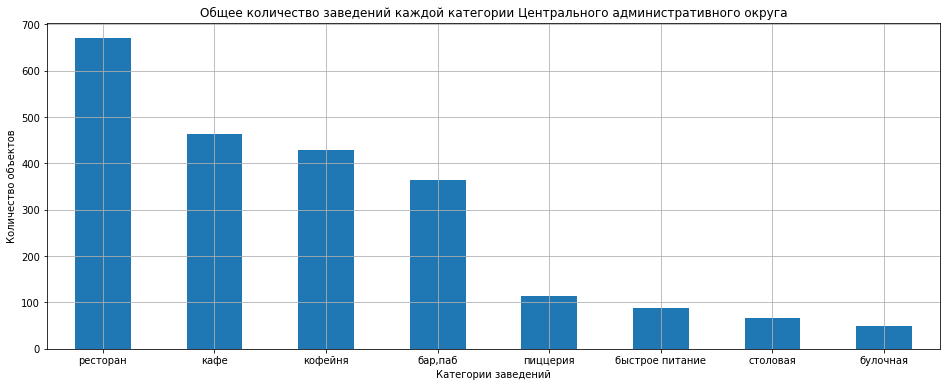

In [46]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(16, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df_moscow_district['category'].value_counts().plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Общее количество заведений каждой категории Центрального административного округа'
)

# Настраиваем оформление графика
plt.xlabel('Категории заведений')
plt.ylabel('Количество объектов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

</font><font color='Blue'><b>
- В Центральном округе структура заведений смещена в сторону премиального сегмента: рестораны занимают 30,1% - это максимальная доля среди всех округов, кафе (20,1%) и кофейни (19,3%), а также бары и пабы (16,5%) формируют среднюю ценовую группу, в аутсайдерах - пиццерии, фастфуд, столовые, булочные
    
- Бизнес-смысл: Открывать в ЦАО столовую (2,9%) или булочную (2,3%) - рискованно из-за низкого спроса в этой локации, если только это не рядом с офисами/вузами, где есть востребованность на быстрый перекус и не высокий бюджет. Пиццерии (5,1%) и фастфуд (3,8%) - форматы, уступающие по востребованности ресторанам и кофейням

- Рекомендация - Для заведения в ЦАО выбирайте формат ресторан, кафе или кофейня, фастфуд и столовые оставьте для районов, где есть попадание небольшй бюджет и относительную дальность от центра
</b></font><br>

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

In [47]:
# Проверяем распределение данных по значениям столбца chain
print('Распределение данных по значениям столбца chain:')
df['chain'].value_counts()

Распределение данных по значениям столбца chain:


0    5199
1    3203
Name: chain, dtype: int64

In [48]:
# Проверяем распределение данных по значениям столбца chain в относительных значениях
print('Распределение данных по значениям столбца chain:')
df['chain'].value_counts(normalize = True)

Распределение данных по значениям столбца chain:


0    0.618781
1    0.381219
Name: chain, dtype: float64

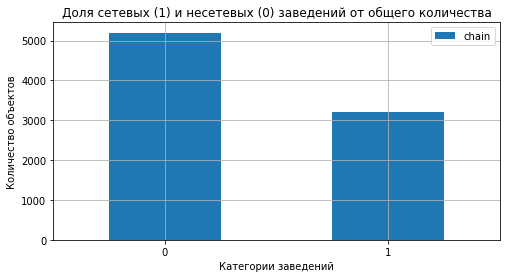

In [49]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(8, 4))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['chain'].value_counts().plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=True, # Включаем легенду
               title=f'Доля сетевых (1) и несетевых (0) заведений от общего количества'
)

# Настраиваем оформление графика
plt.xlabel('Категории заведений')
plt.ylabel('Количество объектов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

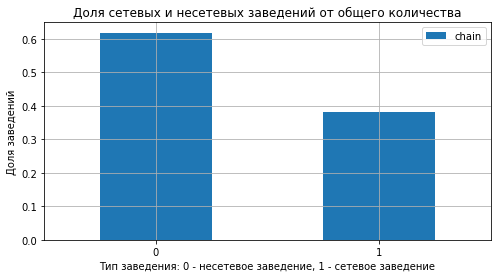

In [50]:
# Создаём контейнер графика matplotlib и задаём его размер 
plt.figure(figsize=(8, 4))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['chain'].value_counts(normalize = True).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=True, # Включаем легенду
               title=f'Доля сетевых и несетевых заведений от общего количества'
)

# Настраиваем оформление графика
plt.xlabel('Тип заведения: 0 - несетевое заведение, 1 - сетевое заведение')
plt.ylabel('Доля заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Ответим на вопрос: `Каких заведений больше — сетевых или несетевых?` - несетевых заведений больше примерно в 1.5 раза:
- несетевых - 4780
-  сетевых - 3087

In [51]:
# Выведем долю сетевых заведений от общего количества
(df.groupby('category')['chain'].sum() / df.groupby('category')['chain'].count()).sort_values(ascending=False)

category
булочная           0.613281
пиццерия           0.521327
кофейня            0.509554
быстрое питание    0.384743
ресторан           0.357003
кафе               0.327862
столовая           0.279365
бар,паб            0.219895
Name: chain, dtype: float64

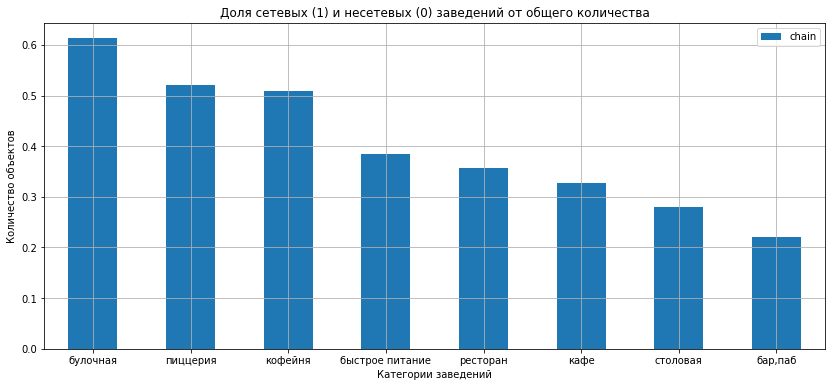

In [52]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(14, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
(df.groupby('category')['chain'].sum() / df.groupby('category')['chain'].count()).sort_values(ascending=False).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=True, # Включаем легенду
               title=f'Доля сетевых (1) и несетевых (0) заведений от общего количества'
)

# Настраиваем оформление графика
plt.xlabel('Категории заведений')
plt.ylabel('Количество объектов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

</font><font color='Blue'><b>
- Рынок общепита Москвы на 61% состоит из несетевых заведений, однако есть категории, где сети доминируют: булочные (62% сетевых), пиццерии (53%), кофейни (51%). В барах сети занимают лишь 21% - здесь каждый предприниматель находит свой подход


- Сетевых заведений почти в 1,5 раза меньше, чем несетевых. Разрыв между лидером (булочные - 62%) и аутсайдером (бары - 21%) составляет 3-кратную разницу


- Если сгруппировать, то все заведения делятся на три группы - высокая сетевизация (>50%) - булочные, пиццерии, кофейни, средняя сетевизация (35-40%) - фастфуд, рестораны, кафе, низкая сетевизация (<30%) - столовые, бары/пабы


- Бизнес-смысл - для открытия заведения булочной или кофейни без сети шансы низки - выоская популярность и колечство заведений, а также сетевые стандарты. А вот открыть бар или столовую - подходящий вариант


- Рекомендация для сетей - открытие булочных/кофеен, если частный предприниматель - выбирайте бары, столовые или кафе, где можно конкурировать не ценой и узнаваемостью, а своим индивидуальным подходом к заведению
</b></font><br>

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


In [53]:
# Посмотрим на распределение значений в 'seats'
print(df['seats'].describe())

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64


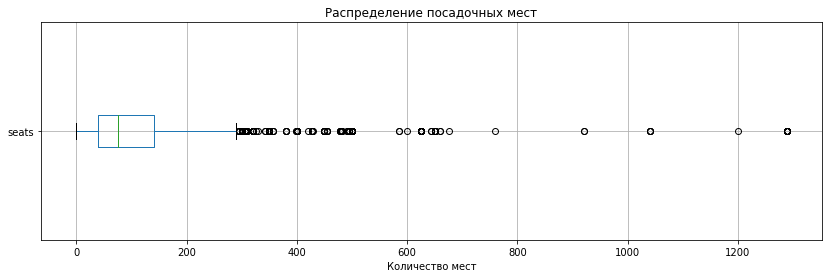

In [54]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(14, 4))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='seats', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение посадочных мест')
plt.xlabel('Количество мест')

# Выводим график
plt.show()

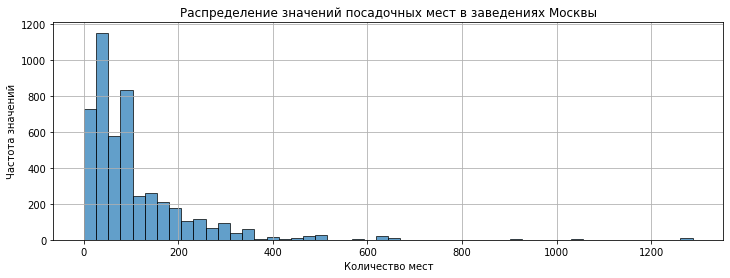

In [55]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 4))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['seats'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин - всего 25
                alpha=0.7,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений посадочных мест в заведениях Москвы')
plt.xlabel('Количество мест')
plt.ylabel('Частота значений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Аномальные значения могут быть связаны:
- с крупными сетевыми ресторанами, ТЦ, фуд-кортами
- с ошибками в данных (0 мест)

In [56]:
# посмотрим на средние значения мест по категориям заведений
df.groupby('category')['seats'].mean().sort_values(ascending = False)

category
бар,паб            124.477516
ресторан           121.892041
кофейня            111.199734
столовая                99.75
быстрое питание     98.891117
кафе                97.365653
пиццерия            94.496487
булочная            89.385135
Name: seats, dtype: Float64

In [57]:
# и медианы количества мест по категориям заведений 
df.groupby('category')['seats'].median().sort_values(ascending = False)

category
ресторан           86.0
бар,паб            82.0
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: Float64

Можем сделать вывод, что есть большой разброс значений между средним и медианой по местам 

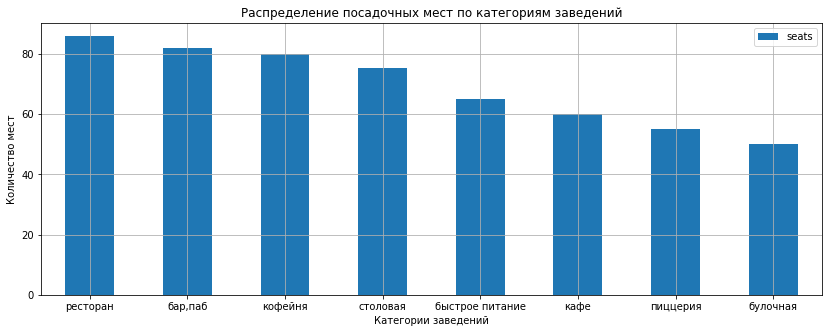

In [58]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(14, 5))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df.groupby('category')['seats'].median().sort_values(ascending = False).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=True, # Включаем легенду
               title=f'Распределение посадочных мест по категориям заведений'
)

# Настраиваем оформление графика
plt.xlabel('Категории заведений')
plt.ylabel('Количество мест')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

</font><font color='Blue'><b>
- Распределение посадочных мест сильно асимметрично. Среднее (108 мест) значительно выше медианы (75 мест) - это признак наличия крупных выбросов. Максимум - 1288 мест, минимум — 0

- Выбросы- аномально большие заведения (500+ мест) - это крупные рестораны в ТЦ, фуд-корты, банкетные залы. Ноль мест - вероятно, что в заведении формат без посадочных мест, на открытом воздухе или "на вынос"

- Типичное значение (медиана) по категориям: лидеры - рестораны (86 мест), бары/пабы (82), кофейни (80), средний сегмент - столовые (74), фастфуд (70), кафе (60), аутсайдеры - пиццерии (55), булочные (50)

- Медиана- надежное значение для анализа заведения, среднее вводит в заблуждение из-за вбросов. Разница между рестораном (86) и булочной (50) почти вдвое - разная бизнес-модель: рестораны делают ставку на длительное пребывание гостя, строгий сервис и высокий чек, ориентируясь при этом на высокий средний чек, булочные - на быстрое обслуживание, невысокий чек

- Рекомендация при открытии заведения - ориентируйтесь на медиану своей категории. Для ресторана закладывайте 80–90 мест - это стандарт для данной категории. Для булочной 50 мест достаточно, больше — избыточная площадь и затраты, профицит. Если планируете ведущее заведение (500+ мест) - готовьте уникальную бизнес-модель (банкетный зал, флагманский ресторан в ТЦ).


</b></font><br>

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [59]:
# посмотрим на распределение значений в 'rating'
df['rating'].describe()

count    8402.000000
mean        4.230016
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

In [60]:
df.groupby('category')['rating'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",764.0,4.387697,0.380392,1.1,4.3,4.4,4.6,5.0
булочная,256.0,4.268360,0.386303,1.3,4.2,4.3,4.4,5.0
быстрое питание,603.0,4.050249,0.560949,1.1,3.9,4.2,4.3,5.0
кафе,2376.0,4.124284,0.566001,1.0,4.0,4.2,4.4,5.0
кофейня,1413.0,4.277282,0.372250,1.4,4.1,4.3,4.4,5.0
пиццерия,633.0,4.301264,0.336162,1.0,4.2,4.3,4.4,5.0
ресторан,2042.0,4.290401,0.413143,1.0,4.2,4.3,4.5,5.0
столовая,315.0,4.211429,0.454205,1.0,4.1,4.3,4.4,5.0


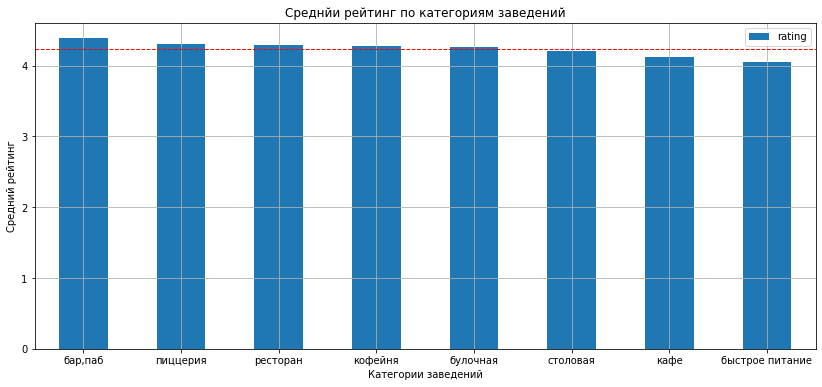

In [61]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(14, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df.groupby('category')['rating'].mean().sort_values(ascending = False).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=True, # Включаем легенду
               title=f'Среднйи рейтинг по категориям заведений'
)

# Настраиваем оформление графика
plt.xlabel('Категории заведений')
plt.ylabel('Средний рейтинг')
# Добавляем сетку графика
plt.grid()

mean_rating = df['rating'].mean()

# Наносим на график линию
plt.axhline(mean_rating, color='red', 
            linestyle='--', linewidth=1,
            label=f'Средний рейтинг по всем данным: {round(mean_rating, 2)}')

# Выводим график
plt.show()

Различия в средних рейтингах между разными типами заведений является незначительным

</font><font color='Blue'><b>
- Средние рейтинги по категориям заведений различаются, но не кардинально
- Максимальный средний рейтинг у баров и пабов (4.39), минимальный — у быстрого питания (4.06). Разница между ними 0.33 балла, что на 5-балльной шкале составляет около 7–10%, что может означать некоторые различия между заведениям с минимальным и максимальным баллом
</b></font><br>

<font color='DarkMagenta'>👉 <b>Бизнес-смысл</b>:
- <b><i>Рекорд баров</i></b>: Если инвестор ищет максимальную лояльность аудитории и защиту от негатива — формат "бар,паб" с завышенной оценкой. Ошибки в сервисе здесь прощают больше, чем в ресторане.
- <b><i>Проблема фастфуда и кафе</i></b>: Рынок этих заведений перегрет и нестабилен. Средняя оценка 4.05 означает, что около половины точек имеют рейтинг ниже 4.0 — это уровень "можно не прийти" для многих гостей. Открывать кафе или фастфуд без четкого стандарта качества или известного бренда очень рискованно.
- <b><i>Столовые</i></b>: Не все столовые дешевые и плохие. Огромный разброс данных (от 1.0 до 5.0) говорит о наличии ниши "премиум-столовых" в бизнес-центрах, которые получают оценки на уровне ресторанов.

<b>Рекомендации</b>
- <b><i>Изучить успешных</i></b>: Стоит отдельно выгрузить бары с рейтингом >4.6 и столовые с рейтингом >4.5, чтобы понять их формулу успеха (меню, акции, расположение).
- <b><i>Избегать "серой зоны"</i></b>: Открывать обычное кафе или рядовую бургерную сейчас невыгодно — конкуренция завалила этот сегмент низкими оценками.
- <b><i>Инвестиции в качество</i></b>: В сегменте "быстрого питания" важна не цена, а стабильность. Учитывая высокий стандартный разброс отметок, заведение с четким сервисом (рейтинг 4.5+) легко вырвется вперед, так как средняя температура по больнице низкая.</font>

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [62]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['category', 'district', 'chain', 'seats', 'price', 'is_24_7', 'rating']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.262056
category,0.198739
district,0.189453
is_24_7,0.161010
chain,0.118857
seats,0.000000


Из всех связей можем отметить самую сильную, между рейтингом и ценами - 0.26

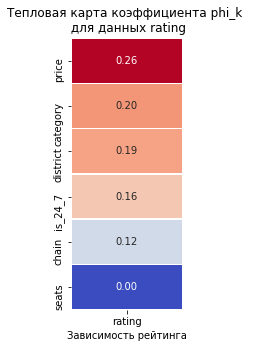

In [63]:
# Строим тепловую карту
plt.figure(figsize=(2, 5))

# Сохраняем матрицу корреляции признака churn с другими признаками клиента
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Зависимость рейтинга')

# Выводим график
plt.show()

In [64]:
# сгруппируем ценовые категории по рейтингу 
df.groupby('price')['rating'].mean()

price
высокие          4.436611
выше среднего    4.386348
низкие           4.173077
средние          4.297874
Name: rating, dtype: float32

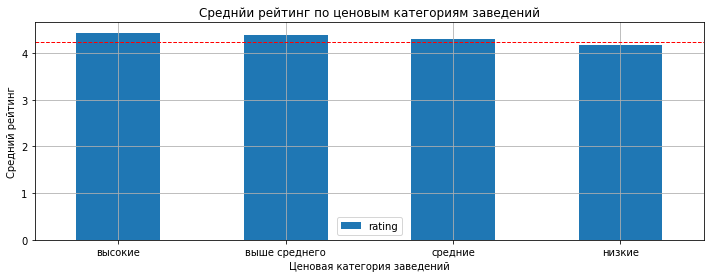

In [65]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 4))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df.groupby('price')['rating'].mean().sort_values(ascending = False).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=True, # Включаем легенду
               title=f'Среднйи рейтинг по ценовым категориям заведений'
)

# Настраиваем оформление графика
plt.xlabel('Ценовая категория заведений')
plt.ylabel('Средний рейтинг')
# Добавляем сетку графика
plt.grid()

mean_rating = df['rating'].mean()

# Наносим на график линию
plt.axhline(mean_rating, color='red', 
            linestyle='--', linewidth=1,
            label=f'Средний рейтинг по всем данным: {round(mean_rating, 2)}')

# Выводим график
plt.show()

Существует низкая положительная свзяь между ценой и рейтингом - 0.26, остальные коэффициэнты имеют еще более низкие показатели

</font><font color='Blue'><b>
- Наблюдается слабая положительная корреляция (0.26) между ценовой категорией заведения и рейтингом. Это означает, что в целом заведения с более высокими ценами имеют тенденцию к немного более высоким рейтингам
</b></font><br>

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [66]:
# Топ-15 популярных сетей по количеству заведений в Москве
df.groupby('name')['id'].count().sort_values(ascending = False).head(15)

name
кафе                                   188
шоколадница                            120
домино'с пицца                          77
додо пицца                              74
one price coffee                        72
яндекс лавка                            69
cofix                                   65
prime                                   50
хинкальная                              44
шаурма                                  43
кофепорт                                42
кулинарная лавка братьев караваевых     39
теремок                                 38
чайхана                                 37
ресторан                                34
Name: id, dtype: int64

In [67]:
# Топ-15 популярных заведений по количеству объектов с фильтрацией дататфрейма, где заведение - сетевое
df_chain = df[df['chain'] == True]
df_chain.groupby('name')['id'].count().sort_values(ascending = False).head(15)

name
шоколадница                            120
домино'с пицца                          76
додо пицца                              74
one price coffee                        71
яндекс лавка                            69
cofix                                   65
prime                                   50
хинкальная                              44
кофепорт                                42
кулинарная лавка братьев караваевых     39
теремок                                 38
чайхана                                 37
cofefest                                32
буханка                                 32
му-му                                   27
Name: id, dtype: int64

In [68]:
# Создадим сводную таблицу топ-15 сетевых заведений по популярности с категориями и средним рейтингом
df_chain.groupby(['name', 'category']).agg({
    'id' : 'count',
    'rating' : 'mean'
}).sort_values(by = 'id', ascending = False).head(16).reset_index()

,name,category,id,rating
0,шоколадница,кофейня,119,4.178151
1,домино'с пицца,пиццерия,76,4.169737
2,додо пицца,пиццерия,74,4.286487
3,one price coffee,кофейня,71,4.064789
4,яндекс лавка,ресторан,69,3.872464
5,cofix,кофейня,65,4.075385
6,prime,ресторан,49,4.114285
7,кофепорт,кофейня,42,4.147619
8,кулинарная лавка братьев караваевых,кафе,39,4.394872
9,теремок,ресторан,36,4.105556


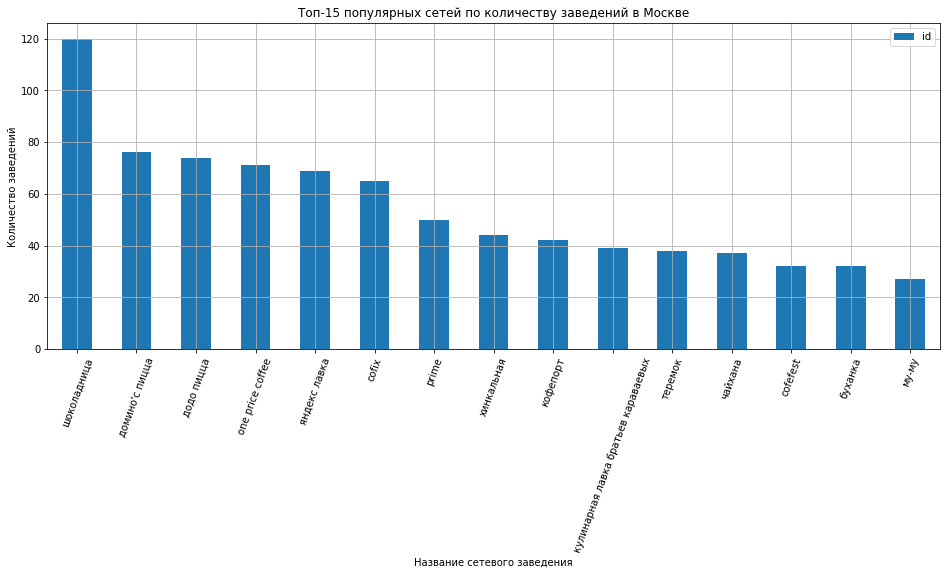

In [69]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(16, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df_chain.groupby('name')['id'].count().sort_values(ascending = False).head(15).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=70, # Градус вращения подписи по оси Х
               legend=True, # Включаем легенду
               title=f'Топ-15 популярных сетей по количеству заведений в Москве'
)

# Настраиваем оформление графика
plt.xlabel('Название сетевого заведения')
plt.ylabel('Количество заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

In [70]:
# значения среднего рейтинга для топ-15 популярных сетей по количеству заведений
df_chain.groupby('name').agg({'id': 'count', 'rating': 'mean'}).sort_values(by = 'id', ascending = False).head(15)

,id,rating
name,,
шоколадница,120,4.177500
домино'с пицца,76,4.169737
додо пицца,74,4.286487
one price coffee,71,4.064789
яндекс лавка,69,3.872464
cofix,65,4.075385
prime,50,4.116000
хинкальная,44,4.322727
кофепорт,42,4.147619


In [71]:
# посмотрим к какой категории заведений относятся топ-15 сетей по популярности заведений
df_chain.groupby(['name', 'category'])['id'].count().sort_values(ascending = False).head(15)

name                                 category
шоколадница                          кофейня     119
домино'с пицца                       пиццерия     76
додо пицца                           пиццерия     74
one price coffee                     кофейня      71
яндекс лавка                         ресторан     69
cofix                                кофейня      65
prime                                ресторан     49
кофепорт                             кофейня      42
кулинарная лавка братьев караваевых  кафе         39
теремок                              ресторан     36
cofefest                             кофейня      31
чайхана                              кафе         26
буханка                              булочная     25
drive café                           кафе         24
кофемания                            кофейня      22
Name: id, dtype: int64

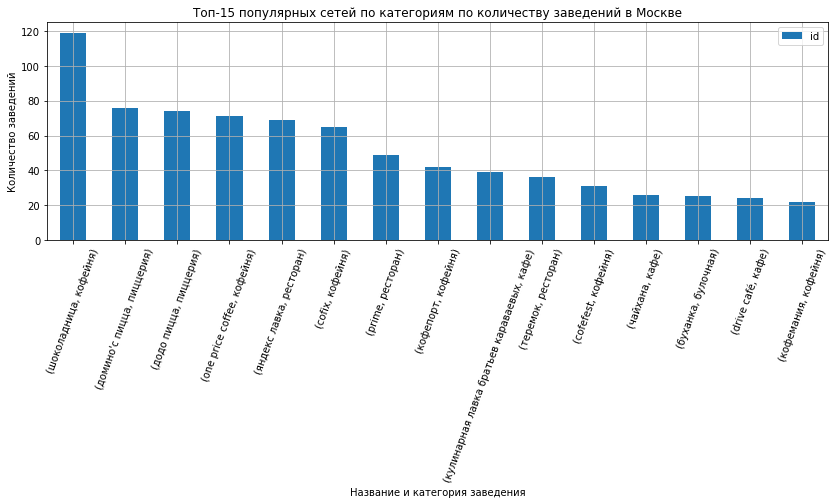

In [72]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(14, 4))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df_chain.groupby(['name', 'category'])['id'].count().sort_values(ascending = False).head(15).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=70, # Градус вращения подписи по оси Х
               legend=True, # Включаем легенду
               title=f'Топ-15 популярных сетей по категориям по количеству заведений в Москве'
)

# Настраиваем оформление графика
plt.xlabel('Название и категория заведения')
plt.ylabel('Количество заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

</font><font color='Blue'><b>
- Среди сетевых заведений Москвы лидером по распространённости является «шоколадница» (120 заведений) - это около в полтора раза больше, чем у ближайшего представителя - «домино'с пицца» (76 заведений). В целом в топ-15 доминируют два сегмента: кофейни (7 сетей) и рестораны быстрого питания/пиццерии (4 сети). На их долю приходится более 70% всех заведений из топа

- Высокая популярность сети не гарантирует высокий рейтинг. Например:«шоколадница» (лидер по количеству) имеет средний рейтинг 4,18 - ниже среднего по топу (4,20)

- Самые высокие рейтинги среди топ-15 показывают менее крупные сети: «кофемания» (4,46), «буханка» (4,40), «кулинарная лавка братьев караваевых» (4,39)

- Самый низкий рейтинг - у «яндекс лавки» (3,87) и «чайханы» (3,96), при этом обе сети входят в топ-15 по числу точек.

- Масштабирование сети не всегда являетися показателем высокого ерйтинга. Для сетей-лидеров («шоколадница», «домино'с пицца») рекомендуется точечный аудит точек с низкими оценками. Наоборот, сети с высоким рейтингом, но малым числом точек («кофемания», «буханка») - показывают рейтинг выше, а значит и показатели довольного клиента

- При выборе локации для нового заведения стоит ориентироваться не только на узнаваемость сети, но и на её реальный рейтинг — высокие оценки в малых сетях могут сигнализировать о лучшем качестве продукции, сервисе, атмосфере заведения
</b></font><br>

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


In [73]:
# Смотрим на статистические значения среднего чека
df['middle_avg_bill'].describe()

count     3149.000000
mean       958.053650
std       1009.732849
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

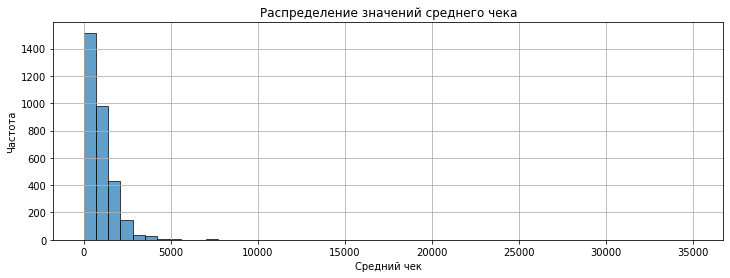

In [74]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 4))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['middle_avg_bill'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин - всего 25
                alpha=0.7,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

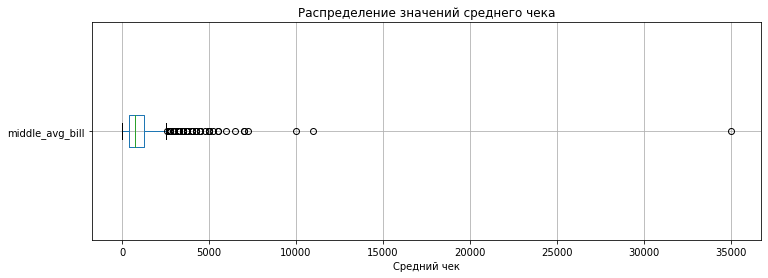

In [75]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 4))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='middle_avg_bill', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')

# Выводим график
plt.show()

In [76]:
# Посмотрим как администартивный округ влияет на средний чек
df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending = False).head(10)

district
Центральный         1191.057495
Западный            1053.225464
Северный             927.959656
Южный                834.398071
Северо-Западный      822.222900
Восточный            820.626953
Юго-Западный         792.561707
Северо-Восточный     716.611267
Юго-Восточный        654.097961
Name: middle_avg_bill, dtype: float32

In [77]:
# выводим медианные и средние значения среднего ека для каждого ракйона 
df.groupby('district')['middle_avg_bill'].agg(['median', 'mean']).sort_values(by='district', ascending=True)

,median,mean
district,,
Восточный,575.0,820.626953
Западный,1000.0,1053.225464
Северный,650.0,927.959656
Северо-Восточный,500.0,716.611267
Северо-Западный,700.0,822.222900
Центральный,1000.0,1191.057495
Юго-Восточный,450.0,654.097961
Юго-Западный,600.0,792.561707
Южный,500.0,834.398071


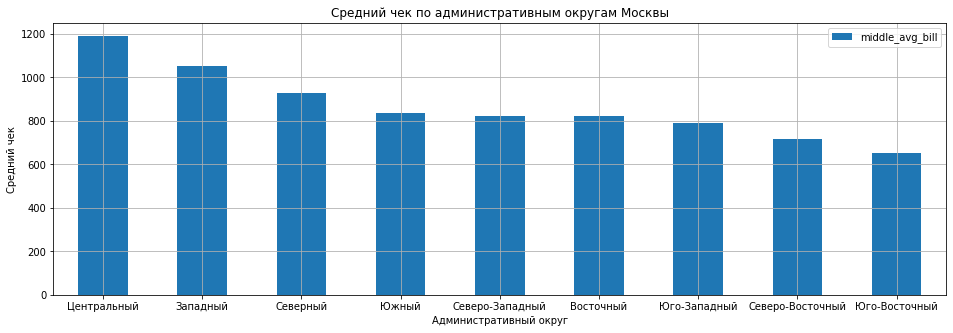

In [78]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(16, 5))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending = False).head(10).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=True, # Включаем легенду
               title=f'Средний чек по административным округам Москвы'
)

# Настраиваем оформление графика
plt.xlabel('Административный округ')
plt.ylabel('Средний чек')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

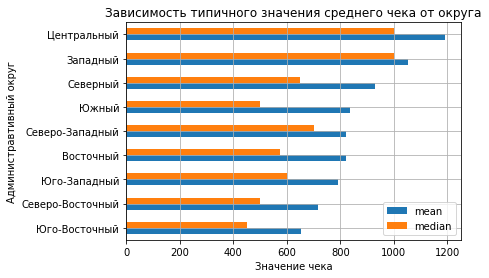

In [79]:
# Создаём контейнер графика matplotlib и задаём его размер

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df.groupby('district')['middle_avg_bill'].agg(['mean', 'median']).sort_values(by = 'mean', ascending=True).plot(
               kind='barh', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=True, # Включаем легенду
               title=f'Зависимость типичного значения среднего чека от округа'
)

# Настраиваем оформление графика
plt.xlabel('Значение чека')
plt.ylabel('Администравтивный округ')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

</font><font color='Blue'><b>
- По мере удаления от центра Москвы средний чек в заведениях снижается: максимальное значение зафиксировано в Центральном округе (1191), затем следуют Западный (1053) и Северный (928), а минимальные чеки - в Юго-Восточном (654) и Северо-Восточном (717) округах, что подтверждает обратную зависимость между ценой заведения и его удалённостью от центральной части города - чем дальше от центра, тем ниже средний чек в заведениях общественного питания
</b></font><br>

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

- В ходе исследовательского анализа данных о заведениях общественного питания Москвы установлено, что наиболее распространёнными категориями являются кафе (2002), рестораны (1968) и кофейни (1398). 
- Центральный административный округ лидирует по количеству заведений (2211), при этом в нём доминируют рестораны, кафе и кофейни. 
- Несетевых заведений больше (4780), чем сетевых (3087), при этом наиболее высокая доля сетей наблюдается в категориях «булочная» (62%), «пиццерия» (53%) и «кофейня» (51%). 
- Выявлены аномальные значения по количеству посадочных мест (максимум 1288), которые связаны с крупными ресторанами и фуд-кортами, а наиболее типичное (медианное) количество мест варьируется от 50 (булочные) до 86 (рестораны). 
- Средние рейтинги заведений различаются незначительно 4.06–4.39, при этом самая сильная корреляция рейтинга выявлена с ценовой категорией - 0,263. 
- Топ-15 популярных сетей возглавляет «Шоколадница» (120 заведений), а средний чек закономерно снижается с удалением от центра: в Центральном округе он составляет 1191, в Юго-Восточном — 654.



## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

**1. Общий обзор проделанной работы:**

- Проведён исследовательский анализ рынка общественного питания Москвы на основе данных о 8406 заведениях. После предобработки - удаление 539 строк с пропусками и дубликатами для анализа осталось 7867 заведений. Изучены категории, районы, соотношение сетевых/несетевых заведений, посадочные места, рейтинги, корреляции, топ-сети и средний чек

**2. Ответы на исследовательские вопросы, или главные выводы:**

- Какие категории преобладают?	Кафе (2002), рестораны (1968), кофейни (1398)
- Какой район лидирует?	Центральный (2211 заведений), в нём доминируют рестораны, кафе, кофейни
- Сетевых или несетевых больше?	Несетевых (4780) больше, чем сетевых (3087), в 1,5 раза
- Какие категории самые сетевые?	Булочные (62%), пиццерии (53%), кофейни (51%)
- Есть ли выбросы по местам?	Да, максимум 1288 мест (крупные рестораны, фуд-корты). Типичное (медиана) — от 50 (булочные) до 86 (рестораны) мест
- Сильно ли различаются рейтинги?	Нет, диапазон 4,06–4,39 — различия незначительны
- Что сильнее всего влияет на рейтинг?	Ценовая категория (коэффициент 0,26), но связь слабая
- Топ-3 популярные сети?	«Шоколадница» (120), «Кафе» (100), «Домино'с пицца» (77)
- Как удалённость от центра влияет на цены?	Чем дальше от центра, тем ниже средний чек: 1191 ₽ (центр) → 654 ₽ (Юго-Восточный округ)

**3. Рекомендации на основе анализа данных:**

- В Центральном округе — высокая конкуренция, но высокий средний чек (1191 ₽). Рекомендуются рестораны, кафе, кофейни (наиболее востребованные категории)
- В спальных районах (Юго-Восточный, Восточный) — низкий средний чек (654–820 ₽), но меньше конкуренции
- Для сетевого бизнеса — наиболее перспективные категории: булочные, пиццерии, кофейни
- На рейтинг сильно не влияют ни категория, ни район, ни сетевость. Главное — качество еды и сервиса

<font color='DarkBlue'><b>
## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

**1. Общий обзор проделанной работы:**

- Проведён исследовательский анализ рынка общественного питания Москвы на основе данных о 8406 заведениях. После предобработки (удаление 4 дубликатов, пропуски в hours не удалялись, а были помечены отдельным столбцом hours_missing) для анализа осталось 8402 заведения. Изучены категории, административные районы, соотношение сетевых/несетевых заведений, посадочные места, рейтинги, корреляции, топ-15 сетей и средний чек



**2. Ответы на исследовательские вопросы, или главные выводы:**

- Какие категории преобладают?	Кафе (28,3%), рестораны (24,3%), кофейни (16,8%) — суммарно ~69% рынка
- Какой район лидирует?	Центральный округ (26,7% всех заведений), затем Северный и Южный (по ~10,6%)
- Сетевых или несетевых больше?	Несетевых 61,9%, сетевых 38,1% (несетевых в 1,6 раза больше)
- Какие категории самые сетевые? Булочные (61,3%), пиццерии (52,1%), кофейни (51,0%)
- Есть ли выбросы по местам? Да, максимум 1288 мест (крупные рестораны, фуд-корты). Типичное (медиана) — от 50 (булочные) до 86 (рестораны) мест
- Сильно ли различаются рейтинги? Диапазон 4,06–4,39 (разница ~7-10%) — различия незначительны
- Что сильнее всего влияет на рейтинг? Ценовая категория (коэффициент 0,26) — слабая положительная связь
- Топ-3 популярные сети? 1. «Шоколадница» (120), 2. «Домино'с пицца» (76), 3. «Додо пицца» (74)
- Как удалённость от центра влияет на цены?	Чем дальше от центра, тем ниже средний чек: с 1191 (Центральный) до 654 (Юго-Восточный)

**3. Рекомендации на основе анализа данных:**

- В Центральном округе — высокая конкуренция, но высокий средний чек (1191). Рекомендуются рестораны, кафе, кофейни (наиболее востребованные категории)
- В спальных районах (Юго-Восточный, Восточный) — низкий средний чек (654–820), но меньше конкуренции
- Для сетевого бизнеса — наиболее перспективные категории: булочные, пиццерии, кофейни
- На рейтинг сильно не влияют ни категория, ни район, ни сетевость. Главное — качество еды и сервиса
</b></font><br>